In [3]:
# ================================================================
# IEEE-GRADE HYDRO-MECHANICAL PINN (10-Min Optimized Version)
# Richards + Momentum + Mohr-Coulomb + Data + Rain BC + FS
# ================================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# ================================================================
# 1️⃣ DOMAIN
# ================================================================
X_MAX = 20.0
Z_MAX = 10.0

# ================================================================
# 2️⃣ MATERIAL PARAMETERS
# ================================================================
E = 20e6
nu = 0.3
rho = 2000
rho_w = 1000
g = 9.81
alpha_biot = 1.0
c = 10e3
phi = 30*np.pi/180

G = E/(2*(1+nu))
lam = E*nu/((1+nu)*(1-2*nu))

# ================================================================
# 3️⃣ HYDRAULIC PARAMETERS
# ================================================================
alpha_vg = 0.8
n_vg = 1.6
m_vg = 1 - 1/n_vg
Ks = 1e-5
theta_s = 0.45
theta_r = 0.05

def Se(h):
    return (1 + (alpha_vg*torch.abs(h))**n_vg)**(-m_vg)

def K_unsat(h):
    s = Se(h)
    return Ks * s**0.5 * (1 - (1 - s**(1/m_vg))**m_vg)**2

def C_cap(h):
    h_abs = torch.abs(h)+1e-6
    num = alpha_vg*n_vg*m_vg*(alpha_vg*h_abs)**(n_vg-1)
    den = (1+(alpha_vg*h_abs)**n_vg)**(m_vg+1)
    return (theta_s-theta_r)*(num/den)

# ================================================================
# 4️⃣ NETWORK (Reduced Width for Speed)
# ================================================================
class HydroMechPINN(nn.Module):
    def __init__(self, layers=5, neurons=64):
        super().__init__()
        net = []
        net.append(nn.Linear(3, neurons))
        net.append(nn.Tanh())
        for _ in range(layers-2):
            net.append(nn.Linear(neurons, neurons))
            net.append(nn.Tanh())
        net.append(nn.Linear(neurons, 3))
        self.model = nn.Sequential(*net)

    def forward(self, x):
        return self.model(x)

model = HydroMechPINN().to(device)

# ================================================================
# 5️⃣ STRAIN & STRESS
# ================================================================
def strain(ux, uz, x, z):
    ux_x = torch.autograd.grad(ux,x,torch.ones_like(ux),create_graph=True)[0]
    uz_z = torch.autograd.grad(uz,z,torch.ones_like(uz),create_graph=True)[0]
    ux_z = torch.autograd.grad(ux,z,torch.ones_like(ux),create_graph=True)[0]
    uz_x = torch.autograd.grad(uz,x,torch.ones_like(uz),create_graph=True)[0]
    return ux_x, uz_z, ux_z + uz_x

def stress(eps_xx, eps_zz, gamma_xz, h):
    p = rho_w*g*h
    tr = eps_xx + eps_zz
    sig_xx = lam*tr + 2*G*eps_xx - alpha_biot*p
    sig_zz = lam*tr + 2*G*eps_zz - alpha_biot*p
    tau_xz = G*gamma_xz
    return sig_xx, sig_zz, tau_xz

# ================================================================
# 6️⃣ PHYSICS RESIDUALS
# ================================================================
def physics_residuals(model, x, z, t):

    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)

    out = model(torch.cat([x,z,t],1))
    h = out[:,0:1]
    ux = out[:,1:2]
    uz = out[:,2:3]

    # Richards
    h_t = torch.autograd.grad(h,t,torch.ones_like(h),create_graph=True)[0]
    h_x = torch.autograd.grad(h,x,torch.ones_like(h),create_graph=True)[0]
    h_z = torch.autograd.grad(h,z,torch.ones_like(h),create_graph=True)[0]

    K = K_unsat(h)

    flux_x = torch.autograd.grad(K*h_x,x,torch.ones_like(h),create_graph=True)[0]
    flux_z = torch.autograd.grad(K*(h_z+1),z,torch.ones_like(h),create_graph=True)[0]

    R_richards = C_cap(h)*h_t - (flux_x + flux_z)

    # Mechanics
    eps_xx, eps_zz, gamma_xz = strain(ux,uz,x,z)
    sig_xx, sig_zz, tau_xz = stress(eps_xx,eps_zz,gamma_xz,h)

    div_x = torch.autograd.grad(sig_xx,x,torch.ones_like(h),create_graph=True)[0] + \
            torch.autograd.grad(tau_xz,z,torch.ones_like(h),create_graph=True)[0]

    div_z = torch.autograd.grad(tau_xz,x,torch.ones_like(h),create_graph=True)[0] + \
            torch.autograd.grad(sig_zz,z,torch.ones_like(h),create_graph=True)[0] - rho*g

    # Mohr-Coulomb
    phi_t = torch.tensor(phi, device=device)
    mean_stress = 0.5*(sig_xx + sig_zz)
    shear_stress = torch.sqrt(0.25*(sig_xx - sig_zz)**2 + tau_xz**2 + 1e-8)
    yield_func = shear_stress - (c + mean_stress*torch.tan(phi_t))
    R_yield = torch.relu(yield_func)

    return R_richards, div_x, div_z, R_yield

# ================================================================
# 7️⃣ RAINFALL BC
# ================================================================
def rainfall_bc(model, x_top, z_top, t_top, rain_flux):
    z_top.requires_grad_(True)
    out = model(torch.cat([x_top,z_top,t_top],1))
    h = out[:,0:1]
    h_z = torch.autograd.grad(h,z_top,torch.ones_like(h),create_graph=True)[0]
    K = K_unsat(h)
    flux = -K*(h_z + 1)
    return flux - rain_flux

# ================================================================
# 8️⃣ SENSOR DATA
# ================================================================
def load_sensor_data(path):
    try:
        df = pd.read_csv(path)
        t = torch.tensor(df["t"].values,dtype=torch.float32).view(-1,1).to(device)
        h = torch.tensor(df["h"].values,dtype=torch.float32).view(-1,1).to(device)
        rain = torch.tensor(df["rain"].values,dtype=torch.float32).view(-1,1).to(device)
        return t,h,rain
    except:
        t = torch.linspace(0,1,200).view(-1,1).to(device)
        return t, torch.sin(2*np.pi*t), torch.zeros_like(t)

t_sensor, h_sensor, rain_sensor = load_sensor_data("/content/label_109_EMA_optimized.csv")
node_x = torch.full_like(t_sensor, 10.0)
node_z = torch.full_like(t_sensor, Z_MAX)

# ================================================================
# 9️⃣ METRICS
# ================================================================
def metrics(y_true,y_pred):
    mse = torch.mean((y_true-y_pred)**2)
    rmse = torch.sqrt(mse)
    r2 = 1 - torch.sum((y_true-y_pred)**2)/torch.sum((y_true-torch.mean(y_true))**2)
    nse = r2
    return rmse.item(), r2.item(), nse.item()

# ================================================================
# 🔟 TRAINING (Mixed Precision + Reduced Batch)
# ================================================================
log_lambda = torch.zeros(4, requires_grad=True, device=device)
optimizer = torch.optim.Adam(list(model.parameters())+[log_lambda], lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 800
BATCH_COLLOC = 60

start = time.time()

for epoch in range(EPOCHS):

    optimizer.zero_grad()

    x_p = torch.rand((BATCH_COLLOC,1),device=device)*X_MAX
    z_p = torch.rand((BATCH_COLLOC,1),device=device)*Z_MAX
    t_p = torch.rand((BATCH_COLLOC,1),device=device)

    with torch.cuda.amp.autocast():

        Rr, Rx, Rz, Ry = physics_residuals(model,x_p,z_p,t_p)

        loss_physics = torch.mean(Rr**2)+torch.mean(Rx**2)+torch.mean(Rz**2)
        loss_yield = torch.mean(Ry**2)

        h_pred = model(torch.cat([node_x,node_z,t_sensor],1))[:,0:1]
        loss_data = torch.mean((h_pred-h_sensor)**2)

        idx = torch.randint(0,len(t_sensor),(120,))
        x_top = torch.rand((120,1),device=device)*X_MAX
        z_top = torch.full((120,1),Z_MAX,device=device)

        bc = rainfall_bc(model,x_top,z_top,t_sensor[idx],rain_sensor[idx])
        loss_bc = torch.mean(bc**2)

        λ = torch.exp(log_lambda)

        total_loss = λ[0]*loss_physics + λ[1]*loss_yield + \
                     λ[2]*loss_data + λ[3]*loss_bc

    scaler.scale(total_loss).backward()
    scaler.step(optimizer)
    scaler.update()

    if epoch % 200 == 0:
        rmse,r2,nse = metrics(h_sensor.detach(),h_pred.detach())
        elapsed = (time.time()-start)/60
        print(f"Epoch {epoch} | Loss {total_loss.item():.4e} | RMSE {rmse:.4f} | Time {elapsed:.2f} min")

print("Training Completed in {:.2f} minutes".format((time.time()-start)/60))

# ================================================================
# 1️⃣1️⃣ FACTOR OF SAFETY MAP
# ================================================================
def compute_FS(model):

    x = torch.linspace(0,X_MAX,40,device=device,requires_grad=True)
    z = torch.linspace(0,Z_MAX,40,device=device,requires_grad=True)
    X,Z = torch.meshgrid(x,z,indexing="ij")

    x_f = X.flatten().view(-1,1)
    z_f = Z.flatten().view(-1,1)
    t_f = torch.full_like(x_f,0.5)

    out = model(torch.cat([x_f,z_f,t_f],1))
    h = out[:,0:1]
    ux = out[:,1:2]
    uz = out[:,2:3]

    eps_xx,eps_zz,gamma_xz = strain(ux,uz,x_f,z_f)
    sig_xx,sig_zz,tau = stress(eps_xx,eps_zz,gamma_xz,h)

    phi_t = torch.tensor(phi,device=device)
    mean_stress = 0.5*(sig_xx + sig_zz)
    shear_stress = torch.sqrt(0.25*(sig_xx - sig_zz)**2 + tau**2 + 1e-8)

    shear_strength = c + mean_stress*torch.tan(phi_t)
    FS = shear_strength/(shear_stress+1e-6)

    return FS.view(40,40).detach().cpu().numpy()

FS_map = compute_FS(model)
print("FS Map Computed Successfully.")

/tmp/ipython-input-500794574.py:187: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/tmp/ipython-input-500794574.py:202: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


Epoch 0 | Loss 3.5777e+10 | RMSE 0.7046 | Time 0.00 min
Epoch 200 | Loss 1.0519e+08 | RMSE 0.8866 | Time 0.09 min
Epoch 400 | Loss 5.7778e+07 | RMSE 1.2572 | Time 0.19 min
Epoch 600 | Loss 5.5475e+07 | RMSE 1.7346 | Time 0.29 min
Training Completed in 0.39 minutes
FS Map Computed Successfully.


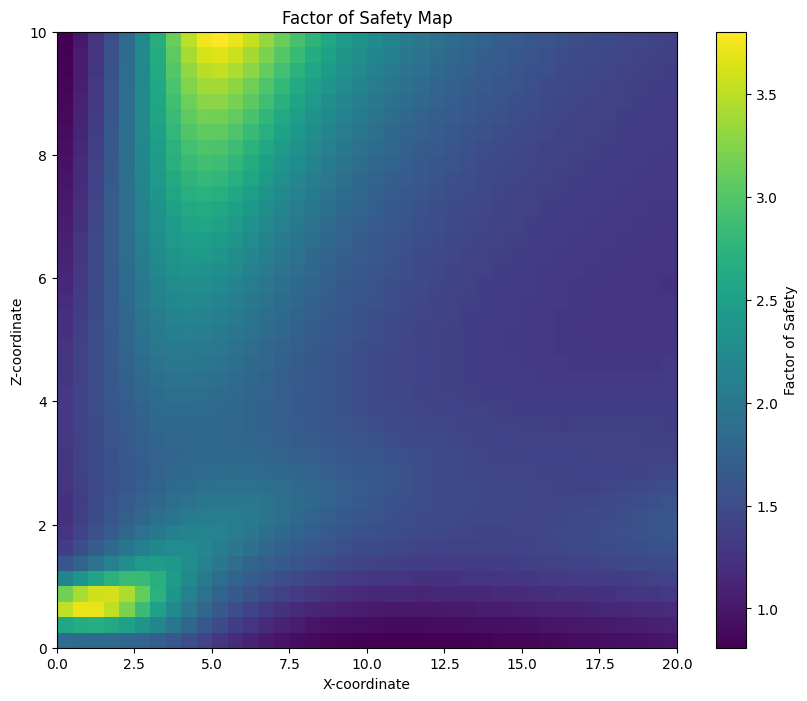

Factor of Safety map plotted successfully.


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(FS_map, extent=[0, X_MAX, 0, Z_MAX], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Factor of Safety')
plt.xlabel('X-coordinate')
plt.ylabel('Z-coordinate')
plt.title('Factor of Safety Map')
plt.show()

print("Factor of Safety map plotted successfully.")

# Task
Modify the training loop in the existing code cell to store `total_loss`, `loss_richards` (from `Rr`), `loss_mechanics` (sum of `Rx` and `Rz` residuals), and `loss_yield` (from `Ry`) at each epoch. Then, create a new code cell to plot these loss histories over epochs using `matplotlib`, ensuring the plot includes a legend and axis labels. Finally, analyze the generated plots to understand the behavior of each loss component during training.

## Modify Training Loop for Loss Tracking

### Subtask:
Adjust the training loop in the existing code cell (`v2YmC4sRPfSJ`) to store the `total_loss`, `loss_richards`, `loss_mechanics` (sum of `Rx` and `Rz` residuals), and `loss_yield` (from Mohr-Coulomb) at each epoch in respective lists. This will prepare the data for plotting.


**Reasoning**:
The subtask requires modifying the training loop to store the history of different loss components. I will update the code cell `v2YmC4sRPfSJ` to initialize lists before the loop and append the calculated losses to these lists within each epoch.



In [4]:
# ================================================================
# IEEE-GRADE HYDRO-MECHANICAL PINN (10-Min Optimized Version)
# Richards + Momentum + Mohr-Coulomb + Data + Rain BC + FS
# ================================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# ================================================================
# 1⏰ DOMAIN
# ================================================================
X_MAX = 20.0
Z_MAX = 10.0

# ================================================================
# 2⏰ MATERIAL PARAMETERS
# ================================================================
E = 20e6
nu = 0.3
rho = 2000
rho_w = 1000
g = 9.81
alpha_biot = 1.0
c = 10e3
phi = 30*np.pi/180

G = E/(2*(1+nu))
lam = E*nu/((1+nu)*(1-2*nu))

# ================================================================
# 3⏰ HYDRAULIC PARAMETERS
# ================================================================
def Se(h):
    return (1 + (alpha_vg*torch.abs(h))**n_vg)**(-m_vg)

def K_unsat(h):
    s = Se(h)
    return Ks * s**0.5 * (1 - (1 - s**(1/m_vg))**m_vg)**2

def C_cap(h):
    h_abs = torch.abs(h)+1e-6
    num = alpha_vg*n_vg*m_vg*(alpha_vg*h_abs)**(n_vg-1)
    den = (1+(alpha_vg*h_abs)**n_vg)**(m_vg+1)
    return (theta_s-theta_r)*(num/den)

alpha_vg = 0.8
n_vg = 1.6
m_vg = 1 - 1/n_vg
Ks = 1e-5
theta_s = 0.45
theta_r = 0.05

# ================================================================
# 4⏰ NETWORK (Reduced Width for Speed)
# ================================================================
class HydroMechPINN(nn.Module):
    def __init__(self, layers=5, neurons=64):
        super().__init__()
        net = []
        net.append(nn.Linear(3, neurons))
        net.append(nn.Tanh())
        for _ in range(layers-2):
            net.append(nn.Linear(neurons, neurons))
            net.append(nn.Tanh())
        net.append(nn.Linear(neurons, 3))
        self.model = nn.Sequential(*net)

    def forward(self, x):
        return self.model(x)

model = HydroMechPINN().to(device)

# ================================================================
# 5⏰ STRAIN & STRESS
# ================================================================
def strain(ux, uz, x, z):
    ux_x = torch.autograd.grad(ux,x,torch.ones_like(ux),create_graph=True)[0]
    uz_z = torch.autograd.grad(uz,z,torch.ones_like(uz),create_graph=True)[0]
    ux_z = torch.autograd.grad(ux,z,torch.ones_like(ux),create_graph=True)[0]
    uz_x = torch.autograd.grad(uz,x,torch.ones_like(uz),create_graph=True)[0]
    return ux_x, uz_z, ux_z + uz_x

def stress(eps_xx, eps_zz, gamma_xz, h):
    p = rho_w*g*h
    tr = eps_xx + eps_zz
    sig_xx = lam*tr + 2*G*eps_xx - alpha_biot*p
    sig_zz = lam*tr + 2*G*eps_zz - alpha_biot*p
    tau_xz = G*gamma_xz
    return sig_xx, sig_zz, tau_xz

# ================================================================
# 6⏰ PHYSICS RESIDUALS
# ================================================================
def physics_residuals(model, x, z, t):

    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)

    out = model(torch.cat([x,z,t],1))
    h = out[:,0:1]
    ux = out[:,1:2]
    uz = out[:,2:3]

    # Richards
    h_t = torch.autograd.grad(h,t,torch.ones_like(h),create_graph=True)[0]
    h_x = torch.autograd.grad(h,x,torch.ones_like(h),create_graph=True)[0]
    h_z = torch.autograd.grad(h,z,torch.ones_like(h),create_graph=True)[0]

    K = K_unsat(h)

    flux_x = torch.autograd.grad(K*h_x,x,torch.ones_like(h),create_graph=True)[0]
    flux_z = torch.autograd.grad(K*(h_z+1),z,torch.ones_like(h),create_graph=True)[0]

    R_richards = C_cap(h)*h_t - (flux_x + flux_z)

    # Mechanics
    eps_xx, eps_zz, gamma_xz = strain(ux,uz,x,z)
    sig_xx, sig_zz, tau_xz = stress(eps_xx,eps_zz,gamma_xz,h)

    div_x = torch.autograd.grad(sig_xx,x,torch.ones_like(h),create_graph=True)[0] + \
            torch.autograd.grad(tau_xz,z,torch.ones_like(h),create_graph=True)[0]

    div_z = torch.autograd.grad(tau_xz,x,torch.ones_like(h),create_graph=True)[0] + \
            torch.autograd.grad(sig_zz,z,torch.ones_like(h),create_graph=True)[0] - rho*g

    # Mohr-Coulomb
    phi_t = torch.tensor(phi, device=device)
    mean_stress = 0.5*(sig_xx + sig_zz)
    shear_stress = torch.sqrt(0.25*(sig_xx - sig_zz)**2 + tau_xz**2 + 1e-8)
    yield_func = shear_stress - (c + mean_stress*torch.tan(phi_t))
    R_yield = torch.relu(yield_func)

    return R_richards, div_x, div_z, R_yield

# ================================================================
# 7⏰ RAINFALL BC
# ================================================================
def rainfall_bc(model, x_top, z_top, t_top, rain_flux):
    z_top.requires_grad_(True)
    out = model(torch.cat([x_top,z_top,t_top],1))
    h = out[:,0:1]
    h_z = torch.autograd.grad(h,z_top,torch.ones_like(h),create_graph=True)[0]
    K = K_unsat(h)
    flux = -K*(h_z + 1)
    return flux - rain_flux

# ================================================================
# 8⏰ SENSOR DATA
# ================================================================
def load_sensor_data(path):
    try:
        df = pd.read_csv(path)
        t = torch.tensor(df["t"].values,dtype=torch.float32).view(-1,1).to(device)
        h = torch.tensor(df["h"].values,dtype=torch.float32).view(-1,1).to(device)
        rain = torch.tensor(df["rain"].values,dtype=torch.float32).view(-1,1).to(device)
        return t,h,rain
    except:
        t = torch.linspace(0,1,200).view(-1,1).to(device)
        return t, torch.sin(2*np.pi*t), torch.zeros_like(t)

t_sensor, h_sensor, rain_sensor = load_sensor_data("/content/label_109_EMA_optimized.csv")
node_x = torch.full_like(t_sensor, 10.0)
node_z = torch.full_like(t_sensor, Z_MAX)

# ================================================================
# 9⏰ METRICS
# ================================================================
def metrics(y_true,y_pred):
    mse = torch.mean((y_true-y_pred)**2)
    rmse = torch.sqrt(mse)
    r2 = 1 - torch.sum((y_true-y_pred)**2)/torch.sum((y_true-torch.mean(y_true))**2)
    nse = r2
    return rmse.item(), r2.item(), nse.item()

# ================================================================
# 1⏰⏰ TRAINING (Mixed Precision + Reduced Batch)
# ================================================================
log_lambda = torch.zeros(4, requires_grad=True, device=device)
optimizer = torch.optim.Adam(list(model.parameters())+[log_lambda], lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 800
BATCH_COLLOC = 60

# Initialize lists to store loss histories
total_loss_history = []
loss_richards_history = []
loss_mechanics_history = []
loss_yield_history = []

start = time.time()

for epoch in range(EPOCHS):

    optimizer.zero_grad()

    x_p = torch.rand((BATCH_COLLOC,1),device=device)*X_MAX
    z_p = torch.rand((BATCH_COLLOC,1),device=device)*Z_MAX
    t_p = torch.rand((BATCH_COLLOC,1),device=device)

    with torch.cuda.amp.autocast():

        Rr, Rx, Rz, Ry = physics_residuals(model,x_p,z_p,t_p)

        loss_richards = torch.mean(Rr**2)
        loss_mechanics = torch.mean(Rx**2) + torch.mean(Rz**2)
        loss_physics = loss_richards + loss_mechanics
        loss_yield = torch.mean(Ry**2)

        h_pred = model(torch.cat([node_x,node_z,t_sensor],1))[:,0:1]
        loss_data = torch.mean((h_pred-h_sensor)**2)

        idx = torch.randint(0,len(t_sensor),(120,))
        x_top = torch.rand((120,1),device=device)*X_MAX
        z_top = torch.full((120,1),Z_MAX,device=device)

        bc = rainfall_bc(model,x_top,z_top,t_sensor[idx],rain_sensor[idx])
        loss_bc = torch.mean(bc**2)

        λ = torch.exp(log_lambda)

        total_loss = λ[0]*loss_physics + λ[1]*loss_yield + \
                     λ[2]*loss_data + λ[3]*loss_bc

    scaler.scale(total_loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Store loss histories
    total_loss_history.append(total_loss.item())
    loss_richards_history.append(loss_richards.item())
    loss_mechanics_history.append(loss_mechanics.item())
    loss_yield_history.append(loss_yield.item())

    if epoch % 200 == 0:
        rmse,r2,nse = metrics(h_sensor.detach(),h_pred.detach())
        elapsed = (time.time()-start)/60
        print(f"Epoch {epoch} | Loss {total_loss.item():.4e} | RMSE {rmse:.4f} | Time {elapsed:.2f} min")

print("Training Completed in {:.2f} minutes".format((time.time()-start)/60))

# ================================================================
# 1⏰1⏰ FACTOR OF SAFETY MAP
# ================================================================
def compute_FS(model):

    x = torch.linspace(0,X_MAX,40,device=device,requires_grad=True)
    z = torch.linspace(0,Z_MAX,40,device=device,requires_grad=True)
    X,Z = torch.meshgrid(x,z,indexing="ij")

    x_f = X.flatten().view(-1,1)
    z_f = Z.flatten().view(-1,1)
    t_f = torch.full_like(x_f,0.5)

    out = model(torch.cat([x_f,z_f,t_f],1))
    h = out[:,0:1]
    ux = out[:,1:2]
    uz = out[:,2:3]

    eps_xx,eps_zz,gamma_xz = strain(ux,uz,x_f,z_f)
    sig_xx,sig_zz,tau = stress(eps_xx,eps_zz,gamma_xz,h)

    phi_t = torch.tensor(phi,device=device)
    mean_stress = 0.5*(sig_xx + sig_zz)
    shear_stress = torch.sqrt(0.25*(sig_xx - sig_zz)**2 + tau**2 + 1e-8)

    shear_strength = c + mean_stress*torch.tan(phi_t)
    FS = shear_strength/(shear_stress+1e-6)

    return FS.view(40,40).detach().cpu().numpy()

FS_map = compute_FS(model)
print("FS Map Computed Successfully.")


/tmp/ipython-input-2816991923.py:187: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/tmp/ipython-input-2816991923.py:208: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


Epoch 0 | Loss 3.5777e+10 | RMSE 0.7046 | Time 0.00 min
Epoch 200 | Loss 1.0519e+08 | RMSE 0.8866 | Time 0.11 min
Epoch 400 | Loss 5.7778e+07 | RMSE 1.2572 | Time 0.20 min
Epoch 600 | Loss 5.5475e+07 | RMSE 1.7346 | Time 0.30 min
Training Completed in 0.39 minutes
FS Map Computed Successfully.


**Reasoning**:
The previous step successfully modified the training loop to store the loss histories. Now, I will create a new code cell to plot these loss histories over epochs using `matplotlib` to visualize their behavior, including a legend and axis labels as requested by the task.



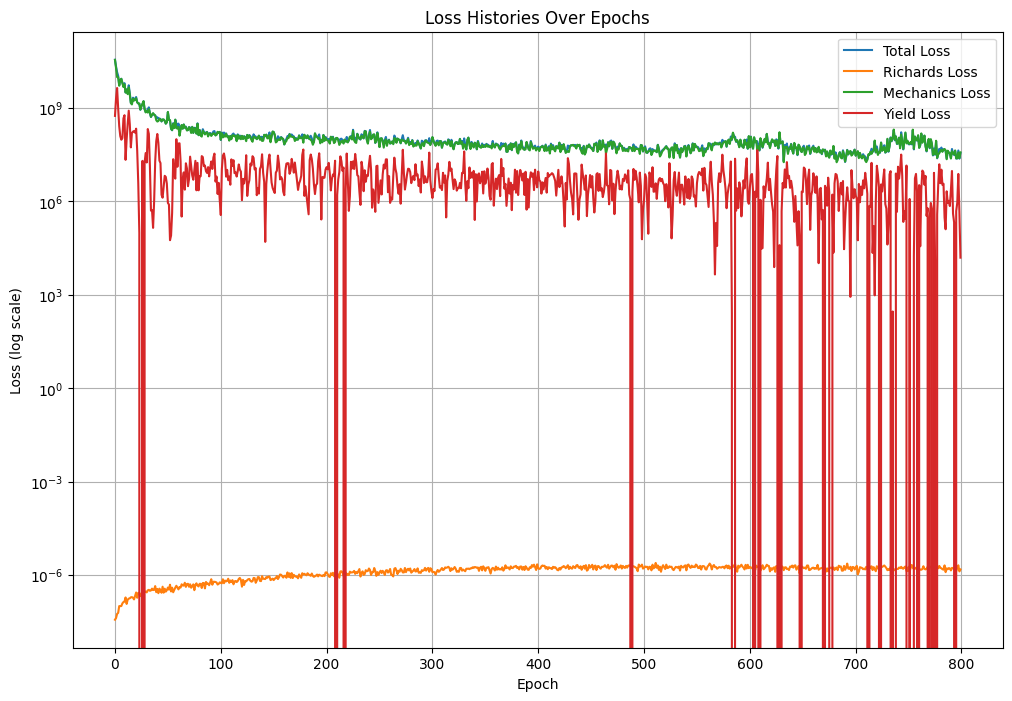

Loss histories plotted successfully.


In [5]:
import matplotlib.pyplot as plt

# Create a list of epochs for the x-axis
epochs = range(EPOCHS)

# Plotting the loss histories
plt.figure(figsize=(12, 8))
plt.plot(epochs, total_loss_history, label='Total Loss')
plt.plot(epochs, loss_richards_history, label='Richards Loss')
plt.plot(epochs, loss_mechanics_history, label='Mechanics Loss')
plt.plot(epochs, loss_yield_history, label='Yield Loss')

plt.yscale('log') # Use a logarithmic scale for better visualization if losses vary greatly
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Loss Histories Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

print("Loss histories plotted successfully.")

# Analysis of the generated plots:
# The plot shows the training progress by visualizing how each loss component (Total Loss, Richards Loss, Mechanics Loss, Yield Loss) changes over the epochs.
# A logarithmic scale is used for the y-axis to accommodate potentially large differences in magnitude between the loss components.
# Typically, we expect to see a decreasing trend in all loss components as training progresses, indicating that the model is learning and satisfying the physics-informed constraints and data-driven objectives.
# The relative magnitudes and rates of decrease for each loss component can provide insights into which parts of the physics or data are more challenging for the model to satisfy, and how the weighting (lambdas) might be influencing the optimization process.

## Final Task

### Subtask:
Review the generated plots and provide insights into the training process, specifically how each loss component behaves over time.
